In [23]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
from scipy.stats import zscore
from scipy.signal import butter, filtfilt

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [25]:
import pandas as pd
import os

path_eeg = "/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A1/EEG_recording.csv"
eeg = pd.read_csv(path_eeg)
eeg.head()

,timestamps,TP9,AF7,AF8,TP10,Right AUX
0,1.624262e+09,34.180,50.781,34.180,-26.367,5.371
1,1.624262e+09,49.316,50.781,20.996,-8.789,-12.207
2,1.624262e+09,50.293,10.742,15.137,-2.441,-27.832
3,1.624262e+09,44.922,-19.043,16.602,-23.926,-33.203
4,1.624262e+09,19.531,20.020,31.250,-48.340,-30.273


In [26]:
# convert timestamps (already in seconds)
eeg['time'] = pd.to_datetime(eeg['timestamps'], unit='s')
eeg = eeg.drop(columns=['timestamps'])
eeg = eeg.set_index('time')

                TP9           AF7           AF8          TP10     Right AUX
count  1.298136e+06  1.298136e+06  1.298136e+06  1.298136e+06  1.298136e+06
mean   3.165144e+01  3.432355e+01  3.265584e+01  2.302151e+01  3.577133e+01
std    1.301369e+02  1.372584e+02  1.137308e+02  1.572454e+02  8.297185e+01
min   -1.000000e+03 -1.000000e+03 -1.000000e+03 -1.000000e+03 -1.000000e+03
25%    1.464800e+01  2.734400e+01  2.441400e+01  9.766000e+00  1.171900e+01
50%    3.271500e+01  3.710900e+01  3.564500e+01  2.832000e+01  3.418000e+01
75%    5.127000e+01  4.687500e+01  4.589800e+01  4.687500e+01  5.712900e+01
max    9.995120e+02  9.995120e+02  9.995120e+02  9.995120e+02  9.995120e+02
TP9          0
AF7          0
AF8          0
TP10         0
Right AUX    0
dtype: int64


<Axes: xlabel='time'>

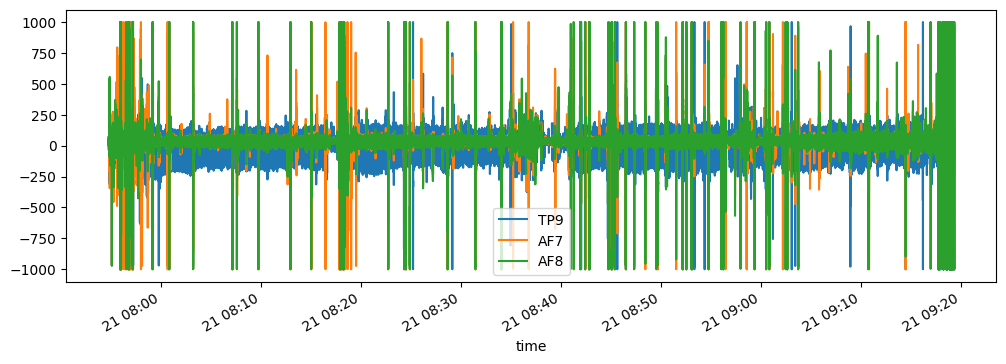

In [27]:
print(eeg.describe())
print(eeg.isnull().sum())

# visualize few channels
eeg[['TP9','AF7','AF8']].plot(figsize=(12,4))

                TP9           AF7           AF8          TP10     Right AUX
count  1.298136e+06  1.298136e+06  1.298136e+06  1.298136e+06  1.298136e+06
mean   3.165144e+01  3.432355e+01  3.265584e+01  2.302151e+01  3.577133e+01
std    1.301369e+02  1.372584e+02  1.137308e+02  1.572454e+02  8.297185e+01
min   -1.000000e+03 -1.000000e+03 -1.000000e+03 -1.000000e+03 -1.000000e+03
25%    1.464800e+01  2.734400e+01  2.441400e+01  9.766000e+00  1.171900e+01
50%    3.271500e+01  3.710900e+01  3.564500e+01  2.832000e+01  3.418000e+01
75%    5.127000e+01  4.687500e+01  4.589800e+01  4.687500e+01  5.712900e+01
max    9.995120e+02  9.995120e+02  9.995120e+02  9.995120e+02  9.995120e+02

Missing values:
 TP9          0
AF7          0
AF8          0
TP10         0
Right AUX    0
dtype: int64


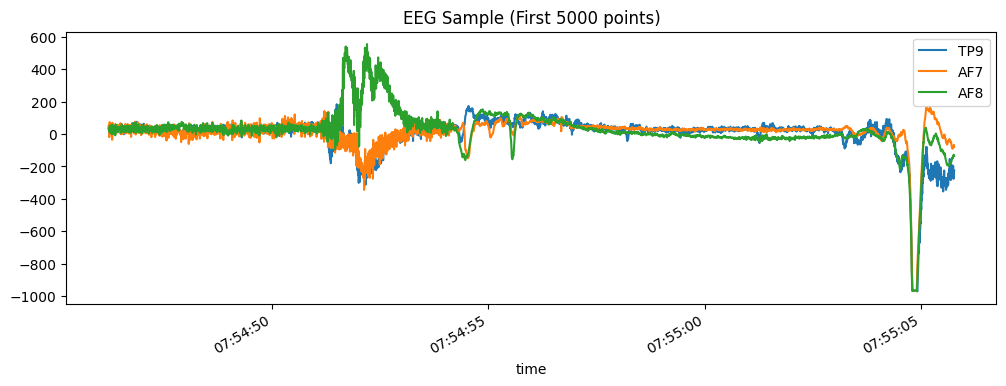

In [28]:
print(eeg.describe())
print("\nMissing values:\n", eeg.isnull().sum())

# plot only small subset
eeg[['TP9','AF7','AF8']].iloc[:5000].plot(figsize=(12,4))
plt.title("EEG Sample (First 5000 points)")
plt.show()

In [29]:
# clip extreme spikes
eeg = eeg.clip(lower=-200, upper=200)

# optional: remove extreme outliers
z = np.abs(zscore(eeg))
eeg = eeg[(z < 5).all(axis=1)]

In [30]:
def bandpass_filter(data, low=0.5, high=40, fs=256):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data)

for col in eeg.columns:
    eeg[col] = bandpass_filter(eeg[col])

In [31]:
scaler = StandardScaler()
eeg_scaled = pd.DataFrame(
    scaler.fit_transform(eeg),
    columns=eeg.columns,
    index=eeg.index
)

In [32]:
path_tags = "/kaggle/input/datasets/ajeetkumar20/brainwear-ds/regulation-of-brain-cognitive-states-through-auditory-gustatory-and-olfactory-stimulation-with-wearable-monitoring-1.0.0/Experiment_1/A1/tags.csv"

tags = pd.read_csv(path_tags)
tags.columns = ["time"]
tags["time"] = pd.to_datetime(tags["time"], unit='s')

In [33]:
eeg_scaled['label'] = 0

for t in tags['time']:
    eeg_scaled.loc[
        (eeg_scaled.index >= t) & 
        (eeg_scaled.index <= t + pd.Timedelta(seconds=5)),
        'label'
    ] = 1

label
0    1267032
1       8801
Name: count, dtype: int64


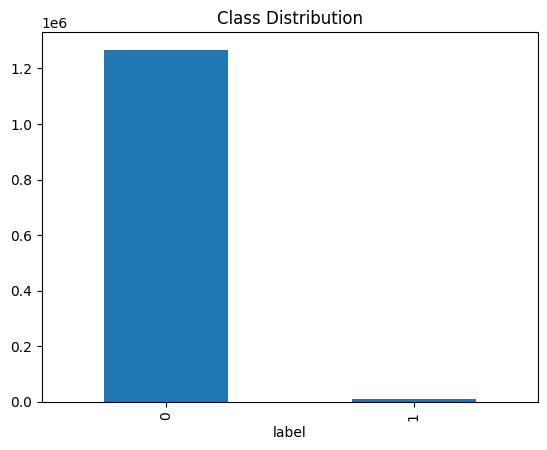

In [35]:
print(eeg_scaled['label'].value_counts())

eeg_scaled['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

In [41]:
window_size = 128
stride = 64

X = []
y = []

values = eeg_scaled.drop(columns=['label']).values
labels = eeg_scaled['label'].values

for i in range(0, len(values) - window_size, stride):
    window = values[i:i+window_size]
    label_window = labels[i:i+window_size]
    
    # robust labeling
    label = 1 if np.mean(label_window) > 0.3 else 0
    
    X.append(window)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("After windowing:")
print(pd.Series(y).value_counts())

After windowing:
0    19790
1      143
Name: count, dtype: int64


In [42]:
def extract_features(window):
    feats = []
    for ch in range(window.shape[1]):
        signal = window[:, ch]
        feats.extend([
            np.mean(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal)
        ])
    return feats

X_final = np.array([extract_features(w) for w in X])
y_final = y

print("Data Matrix shape:", X_final.shape)
print("Label Matrix shape:", y_final.shape)

Data Matrix shape: (19933, 20)
Label Matrix shape: (19933,)


In [43]:
print(pd.Series(y_final).value_counts())
print(np.any(np.isnan(X_final)))   # should be False
print(np.any(np.isinf(X_final)))   # should be False

0    19790
1      143
Name: count, dtype: int64
False
False
